In [11]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import joblib

# Set explicit repository and service paths
repo_root = Path(r"C:\Users\Harsh\AeroSentinel")
ai_service_dir = repo_root / "ai-service"

if str(ai_service_dir) not in sys.path:
    sys.path.insert(0, str(ai_service_dir))

# Resolve processed datasets
train_path = repo_root / "data" / "processed" / "train_dataset.parquet"
val_path = repo_root / "data" / "processed" / "val_dataset.parquet"

# Fallback search if moved
if not train_path.exists():
    train_path = list(repo_root.rglob("train_dataset.parquet"))[0]
if not val_path.exists():
    val_path = list(repo_root.rglob("val_dataset.parquet"))[0]

train_df = pd.read_parquet(train_path)
val_df = pd.read_parquet(val_path)

print(f"Loaded Train: {len(train_df):,} | Val: {len(val_df):,}")
print(f"Data source: {train_path}")

Loaded Train: 49,120 | Val: 10,528
Data source: C:\Users\Harsh\AeroSentinel\data\processed\train_dataset.parquet


Train Hotspot Class Distribution: 13.29% positive (N=6,526)
Val Hotspot Class Distribution:   0.37% positive (N=39)


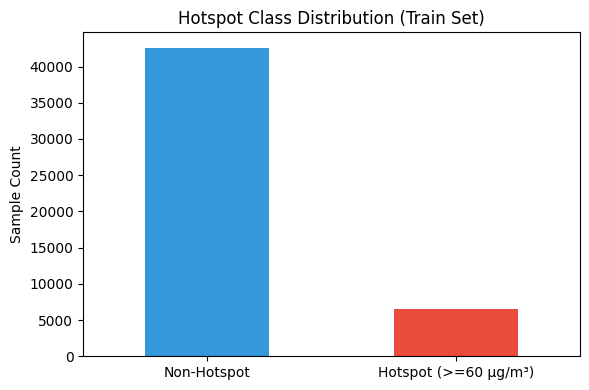

In [12]:
# Target distribution inspection (Section 8 & 10)
target_col = "pm25_clean" if "pm25_clean" in train_df.columns else "pm25"
y_train = (train_df[target_col].fillna(0.0) >= 60.0).astype(int)
y_val = (val_df[target_col].fillna(0.0) >= 60.0).astype(int)

train_pos_rate = y_train.mean() * 100
val_pos_rate = y_val.mean() * 100

print(f"Train Hotspot Class Distribution: {train_pos_rate:.2f}% positive (N={y_train.sum():,})")
print(f"Val Hotspot Class Distribution:   {val_pos_rate:.2f}% positive (N={y_val.sum():,})")

fig, ax = plt.subplots(figsize=(6, 4))
pd.Series({"Non-Hotspot": (y_train == 0).sum(), "Hotspot (>=60 µg/m³)": (y_train == 1).sum()}).plot(
    kind="bar", ax=ax, color=["#3498db", "#e74c3c"]
)
ax.set_ylabel("Sample Count")
ax.set_title("Hotspot Class Distribution (Train Set)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

c:\Users\Harsh\AeroSentinel\ai-service\.venv\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.8.0 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Harsh\AeroSentinel\ai-service\.venv\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.8.0 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Harsh\AeroSentinel\ai-service\.venv\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator _SigmoidCal

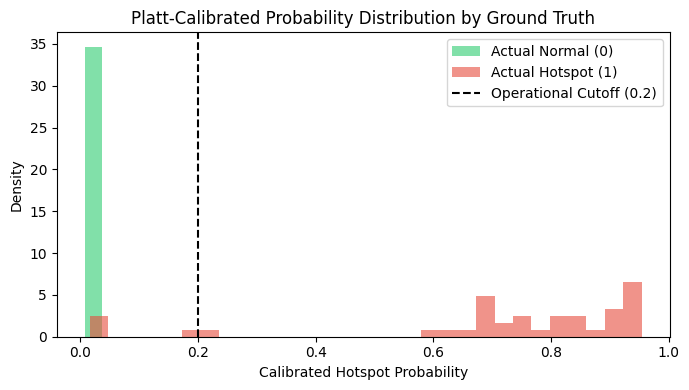

In [13]:
# Load production artifact (Section 12 & 25)
artifact_path = Path("../models/artifacts/hotspot_classifier_v1.joblib")
hotspot_artifact = joblib.load(artifact_path)
model = hotspot_artifact["model"]
features = hotspot_artifact["feature_cols"]
threshold = hotspot_artifact.get("operational_threshold", 0.20)

X_val = val_df[features].fillna(0.0)
val_probs = model.predict_proba(X_val)[:, 1]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(val_probs[y_val == 0], bins=30, alpha=0.6, label="Actual Normal (0)", density=True, color="#2ecc71")
ax.hist(val_probs[y_val == 1], bins=30, alpha=0.6, label="Actual Hotspot (1)", density=True, color="#e74c3c")
ax.axvline(threshold, color="black", linestyle="--", label=f"Operational Cutoff ({threshold})")
ax.set_xlabel("Calibrated Hotspot Probability")
ax.set_ylabel("Density")
ax.set_title("Platt-Calibrated Probability Distribution by Ground Truth")
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, brier_score_loss

# Predictions at default 0.50 cutoff vs operational 0.20 cutoff
y_pred_default = (val_probs >= 0.50).astype(int)
y_pred_operational = (val_probs >= threshold).astype(int)

brier = brier_score_loss(y_val, val_probs)
roc_auc = roc_auc_score(y_val, val_probs)
pr_auc = average_precision_score(y_val, val_probs)

print(f"--- Calibration Quality ---")
print(f"Brier Score: {brier:.4f}")
print(f"ROC-AUC:     {roc_auc:.4f}")
print(f"PR-AUC:      {pr_auc:.4f}")

print("\n--- Operational Report (Threshold = 0.20) ---")
print(classification_report(y_val, y_pred_operational, target_names=["Normal", "Hotspot"]))

--- Calibration Quality ---
Brier Score: 0.0011
ROC-AUC:     0.9996
PR-AUC:      0.8941

--- Operational Report (Threshold = 0.20) ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     10489
     Hotspot       0.72      0.92      0.81        39

    accuracy                           1.00     10528
   macro avg       0.86      0.96      0.90     10528
weighted avg       1.00      1.00      1.00     10528

